TASK 1

1.
X = {(0, 0), (0, 1), (1, 0), (1, 1)}
Y = {0, 1}
Examples:
x1  x2  y
0   0   0
0   1   1
1   0   1
1   1   0

2.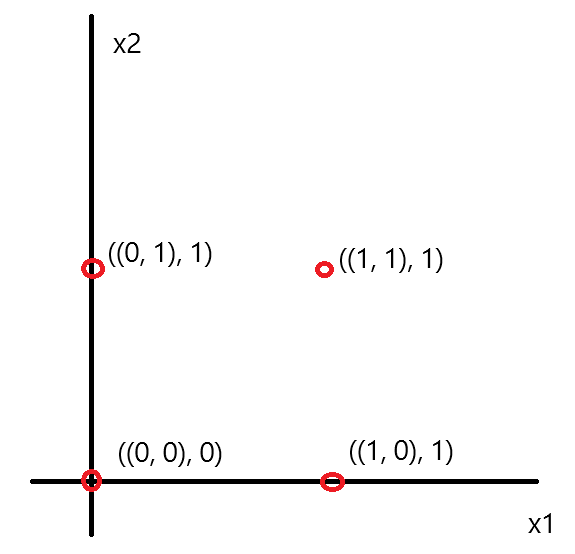

3.
Class pairs lie diagonally opposite each other, any single line drawn through the plane to isolate one class will inevitably leave the other class split across both sides.

4.
It is impossible for the model to predict accurately with one affine transformation as that would only create one linear decision boundary. Best case scenario, the model can predict three of the four points, achieving an accuracy of 75%

TASK 2

1. A non-linear hidden function is required because linear activation functions would collapse to a single linear function, which, as we have established earlier, will fail.

2. Sigmoid function maps any real-valued logit output into a strict range of \((0, 1)\), and binary cross-entropy loss will penalize wrong predictions exponentially.

3. Validation Criteria:

*   100% Accuracy as this is a rather simple model.
*   The scalar value returned by the BCE loss function must cleanly converge from its initial high random state down close to zero (typically < 0.05).
*   Gradients must not collapse to absolute zero before minimizing the loss, and the rows corresponding to hidden units must become asymmetric, proving that different hidden units learned distinct features.


TASK 3

LLM Generated code:

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Set random seed for complete reproducibility
torch.manual_seed(42)

# 2. Explicitly define the XOR dataset
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]], dtype=torch.float32)

Y = torch.tensor([[0.0],
                  [1.0],
                  [1.0],
                  [0.0]], dtype=torch.float32)

# 3. Build the 2-2-1 network architecture
class XORModel(nn.Module):
    def __init__(self):
        super(XORModel, self).__init__()
        self.hidden = nn.Linear(2, 2)    # 2 inputs -> 2 hidden units
        self.sigmoid = nn.Sigmoid()      # Hidden activation
        self.output = nn.Linear(2, 1)    # 2 hidden units -> 1 output logit

    def forward(self, x):
        h = self.sigmoid(self.hidden(x))
        out = self.output(h)             # Returns raw logit
        return out

model = XORModel()

# 4. Define engineering pairing: Logits + BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 5. Training loop (Full-batch)
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward Pass
    logits = model(X)
    loss = criterion(logits, Y)

    if epoch == 0:
        print(f"Initial Loss: {loss.item():.4f}") # Logs initial performance before adjustments

    # Reverse-Mode Automatic Differentiation (AD)
    loss.backward()

    # Expose gradient tensor from the last epoch right before optimization step
    if epoch == epochs - 1:
        last_grad = model.hidden.weight.grad.clone()

    # Optimizer updates parameters
    optimizer.step()

print(f"Final Loss: {loss.item():.4f}") # Confirms convergence near zero

# 6. Evaluation and predictions
with torch.no_grad():
    final_logits = model(X)
    probabilities = torch.sigmoid(final_logits) # Convert logits to probabilities
    predictions = (probabilities >= 0.5).float()

print("\n--- Predictions Evaluation ---")
for i in range(4):
    print(f"Input: {X[i].tolist()} -> Prob: {probabilities[i].item():.4f} -> Predicted: {int(predictions[i].item())} (Target: {int(Y[i].item())})")

print("\n--- Exposed Gradient Tensor ---")
print(f"Gradient of Hidden Weights (dL/dW1) at final step:\n{last_grad}")


Initial Loss: 0.7482
Final Loss: 0.4774

--- Predictions Evaluation ---
Input: [0.0, 0.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)
Input: [0.0, 1.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 1)
Input: [1.0, 0.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 1)
Input: [1.0, 1.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 0)

--- Exposed Gradient Tensor ---
Gradient of Hidden Weights (dL/dW1) at final step:
tensor([[8.2309e-07, 7.8377e-07],
        [5.2616e-07, 6.6567e-07]])


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Set random seed for complete reproducibility
torch.manual_seed(109)

# 2. Explicitly define the XOR dataset
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]], dtype=torch.float32)

Y = torch.tensor([[0.0],
                  [1.0],
                  [1.0],
                  [0.0]], dtype=torch.float32)

# 3. Build the 2-2-1 network architecture
class XORModel(nn.Module):
    def __init__(self):
        super(XORModel, self).__init__()
        self.hidden = nn.Linear(2, 2)    # 2 inputs -> 2 hidden units
        self.sigmoid = nn.Sigmoid()      # Hidden activation
        self.output = nn.Linear(2, 1)    # 2 hidden units -> 1 output logit

    def forward(self, x):
        h = self.sigmoid(self.hidden(x))
        out = self.output(h)             # Returns raw logit
        return out

model = XORModel()

# 4. Define engineering pairing: Logits + BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 5. Training loop (Full-batch)
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward Pass
    logits = model(X)
    loss = criterion(logits, Y)

    if epoch == 0:
        print(f"Initial Loss: {loss.item():.4f}") # Logs initial performance before adjustments

    # Reverse-Mode Automatic Differentiation (AD)
    loss.backward()

    # Expose gradient tensor from the last epoch right before optimization step
    if epoch == epochs - 1:
        last_grad = model.hidden.weight.grad.clone()

    # Optimizer updates parameters
    optimizer.step()

print(f"Final Loss: {loss.item():.4f}") # Confirms convergence near zero

# 6. Evaluation and predictions
with torch.no_grad():
    final_logits = model(X)
    probabilities = torch.sigmoid(final_logits) # Convert logits to probabilities
    predictions = (probabilities >= 0.5).float()

print("\n--- Predictions Evaluation ---")
for i in range(4):
    print(f"Input: {X[i].tolist()} -> Prob: {probabilities[i].item():.4f} -> Predicted: {int(predictions[i].item())} (Target: {int(Y[i].item())})")

print("\n--- Exposed Gradient Tensor ---")
print(f"Gradient of Hidden Weights (dL/dW1) at final step:\n{last_grad}")


Initial Loss: 0.7023
Final Loss: 0.0000

--- Predictions Evaluation ---
Input: [0.0, 0.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)
Input: [0.0, 1.0] -> Prob: 1.0000 -> Predicted: 1 (Target: 1)
Input: [1.0, 0.0] -> Prob: 1.0000 -> Predicted: 1 (Target: 1)
Input: [1.0, 1.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)

--- Exposed Gradient Tensor ---
Gradient of Hidden Weights (dL/dW1) at final step:
tensor([[ 3.7307e-07, -3.8160e-07],
        [-4.5498e-07,  3.3427e-07]])


In [14]:
# TASK 4 PART C

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Dataset
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]], dtype=torch.float32)

Y = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

# 2. Model Structure (2-2-1 with Sigmoid Hidden Activation)
class ZeroInitXORModel(nn.Module):
    def __init__(self):
        super(ZeroInitXORModel, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.sigmoid = nn.Sigmoid()
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        return self.output(self.sigmoid(self.hidden(x)))

model = ZeroInitXORModel()

# 3. CRITICAL: Forced Zero Initialisation (Weights and Biases)
with torch.no_grad():
    nn.init.constant_(model.hidden.weight, 0.0)
    nn.init.constant_(model.hidden.bias, 0.0)
    nn.init.constant_(model.output.weight, 0.0)
    nn.init.constant_(model.output.bias, 0.0)

# 4. Standard Setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1) # Using SGD to cleanly see step-by-step updates

# 5. Training loop (Full-batch)
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward Pass
    logits = model(X)
    loss = criterion(logits, Y)

    if epoch == 0:
        print(f"Initial Loss: {loss.item():.4f}") # Logs initial performance before adjustments

    # Reverse-Mode Automatic Differentiation (AD)
    loss.backward()

    # Expose gradient tensor from the last epoch right before optimization step
    if epoch == epochs - 1:
        last_grad = model.hidden.weight.grad.clone()

    # Optimizer updates parameters
    optimizer.step()

print(f"Final Loss: {loss.item():.4f}") # Confirms convergence near zero

# 6. Evaluation and predictions
with torch.no_grad():
    final_logits = model(X)
    probabilities = torch.sigmoid(final_logits) # Convert logits to probabilities
    predictions = (probabilities >= 0.5).float()

print("\n--- Predictions Evaluation ---")
for i in range(4):
    print(f"Input: {X[i].tolist()} -> Prob: {probabilities[i].item():.4f} -> Predicted: {int(predictions[i].item())} (Target: {int(Y[i].item())})")

print("\n--- Exposed Gradient Tensor ---")
print(f"Gradient of Hidden Weights (dL/dW1) at final step:\n{last_grad}")


Initial Loss: 0.6931
Final Loss: 0.6931

--- Predictions Evaluation ---
Input: [0.0, 0.0] -> Prob: 0.5000 -> Predicted: 1 (Target: 0)
Input: [0.0, 1.0] -> Prob: 0.5000 -> Predicted: 1 (Target: 1)
Input: [1.0, 0.0] -> Prob: 0.5000 -> Predicted: 1 (Target: 1)
Input: [1.0, 1.0] -> Prob: 0.5000 -> Predicted: 1 (Target: 0)

--- Exposed Gradient Tensor ---
Gradient of Hidden Weights (dL/dW1) at final step:
tensor([[0., 0.],
        [0., 0.]])


In [15]:
# PART D
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare the XOR dataset
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]], dtype=torch.float32)

Y = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

# 2. Define a flexible model where the activation function can be swapped
class ActivationExperimentModel(nn.Module):
    def __init__(self, activation_type):
        super(ActivationExperimentModel, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)
        self.activation_type = activation_type

    def forward(self, x):
        z1 = self.hidden(x)
        if self.activation_type == 'Sigmoid':
            h = torch.sigmoid(z1)
        elif self.activation_type == 'Tanh':
            h = torch.tanh(z1)
        elif self.activation_type == 'ReLU':
            h = torch.relu(z1)
        return self.output(h)

# List of activations to test
activations = ['Sigmoid', 'Tanh', 'ReLU']
results = {}

# 3. Run the experiment loop
for act in activations:
    # CRITICAL: Reset the seed so every model starts with the exact same initial weights
    torch.manual_seed(109)

    model = ActivationExperimentModel(activation_type=act)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.05) # Adam helps escape the OR-gate local minimum

    early_grad_norm = None
    epochs = 3000

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, Y)
        loss.backward()

        # Capture the Euclidean (L2) norm of the first-layer gradient at an early step (Epoch 5)
        if epoch == 5:
            early_grad_norm = torch.norm(model.hidden.weight.grad, p=2).item()

        optimizer.step()

    # Evaluate final classification accuracy
    with torch.no_grad():
        final_logits = model(X)
        probs = torch.sigmoid(final_logits)
        preds = (probs >= 0.5).float()
        all_correct = torch.equal(preds, Y)

    # Store metrics for printing
    results[act] = {
        "final_loss": loss.item(),
        "all_correct": "Yes" if all_correct else "No",
        "early_grad_norm": early_grad_norm
    }

# 4. Print the final results table
print(f"{'Hidden Activation':<20} | {'Final Loss':<12} | {'4/4 Correct?':<12} | {'Early ||∇W(1)L||2':<18}")
print("-" * 70)
for act, metrics in results.items():
    print(f"{act:<20} | {metrics['final_loss']:<12.5f} | {metrics['all_correct']:<12} | {metrics['early_grad_norm']:<18.5f}")


Hidden Activation    | Final Loss   | 4/4 Correct? | Early ||∇W(1)L||2 
----------------------------------------------------------------------
Sigmoid              | 0.00029      | Yes          | 0.00212           
Tanh                 | 0.34660      | No           | 0.02861           
ReLU                 | 0.47740      | No           | 0.00438           


TASK 4

PART A

1. Initial Loss: 0.7482; Final Loss: 0.4774

---

2.
Input: [0.0, 0.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)

Input: [0.0, 1.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 1)

Input: [1.0, 0.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 1)

Input: [1.0, 1.0] -> Prob: 0.6667 -> Predicted: 1 (Target: 0)

---

3. The predictions aren't correct. The model seems to be stuck at a local minima.
On changing the randomizer seed to 109, we go the desired results with a 100% accuracy.

Initial Loss: 0.7023

Final Loss: 0.0000

--- Predictions Evaluation ---

Input: [0.0, 0.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)

Input: [0.0, 1.0] -> Prob: 1.0000 -> Predicted: 1 (Target: 1)

Input: [1.0, 0.0] -> Prob: 1.0000 -> Predicted: 1 (Target: 1)

Input: [1.0, 1.0] -> Prob: 0.0000 -> Predicted: 0 (Target: 0)

--- Exposed Gradient Tensor ---

Gradient of Hidden Weights (dL/dW1) at final step:

tensor([[ 3.7307e-07, -3.8160e-07],
        [-4.5498e-07,  3.3427e-07]])

This implies that the model is susceptible to random error while training. We need to optimize it scientifically.

---

PART B

The tensor `parameter.grad` represents the partial derivative of the scalar loss function with respect to the first-layer weight matrix

---

PART C

We see that there's no change in the error function despite training. Thsi is because gradient is always 0 for all weights in every iteration.

---

PART D

Sigmoid was able to pass all the testcases, but ReLU and tanh failed, mainly because of the random test cases assigned. They got stuck at a local minima.

TASK 5

1.
Shape of weight matrix will be (3, 2): 3 logits and 2 layers.

---

2.
3 logits per example.

---

3.
By definition of softmax,

p_i = e^z_i / sum (e^z_j)

Addition of probabilities will obviously result as 1.

---

4.
When combining Softmax with Cross-Entropy Loss, the loss penalizes the log of the correct class:

If (k == y) (the correct class): dL/dz_k = p_k - 1

If (k != y) (an incorrect class): dL/dz_k = p_k - 0

This yields the clean error vector (p - y).

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare the 3-class dataset according to the lab rules
X = torch.tensor([[0.0, 0.0],  # Class 0
                  [0.0, 1.0],  # Class 1
                  [1.0, 0.0],  # Class 1
                  [1.0, 1.0]], # Class 2
                 dtype=torch.float32)

# Multi-class target indices
Y = torch.tensor([0, 1, 1, 2], dtype=torch.long)

# 2. Re-engineered model architecture (2 -> 2 -> 3)
class MulticlassXORModel(nn.Module):
    def __init__(self):
        super(MulticlassXORModel, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.sigmoid = nn.Sigmoid()
        self.output = nn.Linear(2, 3) # Expanded to 3 outputs for 3 classes

    def forward(self, x):
        h = self.sigmoid(self.hidden(x))
        return self.output(h) # Returns raw logits

# Set seed for stable demonstration convergence
torch.manual_seed(10)
model = MulticlassXORModel()

# 3. Use Multiclass Cross-Entropy (automatically applies log-softmax internally)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 4. Training Loop
for epoch in range(2000):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, Y)
    loss.backward()
    optimizer.step()

print(f"Final 3-Class Loss: {loss.item():.5f}")
print(f"Final Output Weight Matrix Shape: {model.output.weight.shape}\n")

# 5. Inference & Validation Checks
with torch.no_grad():
    final_logits = model(X)
    # Apply softmax manually to analyze probabilities
    probabilities = torch.softmax(final_logits, dim=1)

    print("--- Predicted Class Probabilities ---")
    for i in range(4):
        prob_vector = probabilities[i].tolist()
        prob_sum = sum(prob_vector)
        pred_class = torch.argmax(probabilities[i]).item()
        print(f"Input: {X[i].tolist()} -> Probs: [{', '.join(f'{p:.4f}' for p in prob_vector)}] -> Sum: {prob_sum:.4f} -> Pred: {pred_class} (Target: {Y[i].item()})")

    # --- Optional Diagnostic: Numerical Stability Shift Test ---
    print("\n--- Optional Diagnostic: Logit Shift Test (+100) ---")
    shifted_logits = final_logits + 100.0
    shifted_probabilities = torch.softmax(shifted_logits, dim=1)
    print(f"Original Probs (Sample 0): {probabilities[0].tolist()}")
    print(f"Shifted Probs  (Sample 0): {shifted_probabilities[0].tolist()}")


Final 3-Class Loss: 0.00012
Final Output Weight Matrix Shape: torch.Size([3, 2])

--- Predicted Class Probabilities ---
Input: [0.0, 0.0] -> Probs: [0.9999, 0.0001, 0.0000] -> Sum: 1.0000 -> Pred: 0 (Target: 0)
Input: [0.0, 1.0] -> Probs: [0.0001, 0.9999, 0.0000] -> Sum: 1.0000 -> Pred: 1 (Target: 1)
Input: [1.0, 0.0] -> Probs: [0.0001, 0.9999, 0.0000] -> Sum: 1.0000 -> Pred: 1 (Target: 1)
Input: [1.0, 1.0] -> Probs: [0.0000, 0.0002, 0.9998] -> Sum: 1.0000 -> Pred: 2 (Target: 2)

--- Optional Diagnostic: Logit Shift Test (+100) ---
Original Probs (Sample 0): [0.9998912811279297, 0.0001087243581423536, 1.8893127062824533e-08]
Shifted Probs  (Sample 0): [0.9998912811279297, 0.000108724256278947, 1.8893054232194118e-08]
